In [1]:
# basic libs
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import shap
import lime
from lime.lime_text import LimeTextExplainer
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint, uniform

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier




c:\Users\Ali\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

df_raw = pd.read_csv("Phishing_Email.csv",encoding='utf-8',low_memory=False)
df_raw.head()
df_raw = df_raw.drop("Unnamed: 0", axis=1)


In [3]:
df_raw.replace({'Phishing Email': 1, 'Safe Email': 0}, inplace=True)


C:\Users\Ali\AppData\Local\Temp\ipykernel_26420\1504829841.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_raw.replace({'Phishing Email': 1, 'Safe Email': 0}, inplace=True)


In [4]:
X = df_raw["Email Text"]
y = df_raw["Email Type"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [6]:
# Before vectorization
X_train = X_train.fillna("")
X_test = X_test.fillna("")

tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)



In [7]:
lr = LogisticRegression(max_iter=300)
lr.fit(X_train_tfidf, y_train)

lr_pred = lr.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))


Logistic Regression Accuracy: 0.9621983914209116
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2264
           1       0.94      0.97      0.95      1466

    accuracy                           0.96      3730
   macro avg       0.96      0.96      0.96      3730
weighted avg       0.96      0.96      0.96      3730



In [8]:

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

nb_pred = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))


Naive Bayes Accuracy: 0.9428954423592494
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      2264
           1       0.95      0.90      0.93      1466

    accuracy                           0.94      3730
   macro avg       0.94      0.94      0.94      3730
weighted avg       0.94      0.94      0.94      3730



In [9]:
rf = RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', random_state=42)  # Reduced n_estimators, added regularization
rf.fit(X_train_tfidf, y_train)

rf_pred = rf.predict(X_test_tfidf)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.9265415549597855
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      2264
           1       0.96      0.85      0.90      1466

    accuracy                           0.93      3730
   macro avg       0.93      0.91      0.92      3730
weighted avg       0.93      0.93      0.93      3730



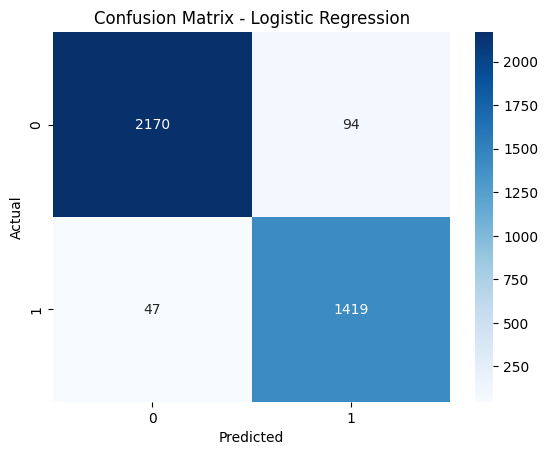

In [10]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [11]:
# LSTM Model Implementation with Save/Load Functionality
import pickle
import os

def build_lstm_model(vocab_size, max_length, embedding_dim=128):
    from tensorflow.keras.regularizers import l2
    
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_length),
        Bidirectional(LSTM(48, return_sequences=True, kernel_regularizer=l2(0.001))),  # Reduced units, added L2 reg
        Dropout(0.5),  # Increased dropout from 0.3 to 0.5
        Bidirectional(LSTM(24, kernel_regularizer=l2(0.001))),  # Reduced units, added L2 reg
        Dropout(0.5),  # Increased dropout from 0.3 to 0.5
        Dense(24, activation='relu', kernel_regularizer=l2(0.001)),  # Reduced units, added L2 reg
        Dropout(0.4),  # Increased dropout from 0.2 to 0.4
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )
    return model

# File paths for saving
model_path = 'lstm_model.keras'
tokenizer_path = 'lstm_tokenizer.pkl'
history_path = 'lstm_history.pkl'
predictions_path = 'lstm_predictions.pkl'

# NOTE: If you want to retrain with the updated architecture (with regularization fixes),
# delete the saved model files above to force retraining.

# Check if model exists
if os.path.exists(model_path) and os.path.exists(tokenizer_path) and os.path.exists(history_path):
    print("Loading saved LSTM model and results...")
    
    # Load model
    lstm_model = tf.keras.models.load_model(model_path)
    
    # Load tokenizer
    with open(tokenizer_path, 'rb') as f:
        tokenizer = pickle.load(f)
    
    # Load history
    with open(history_path, 'rb') as f:
        history_dict = pickle.load(f)
        # Convert dict back to History object-like structure
        class History:
            def __init__(self, history_dict):
                self.history = history_dict
        history = History(history_dict)
    
    # Ensure max_length is set (needed for later cells)
    max_length = 200
    
    # Recreate padded sequences (needed for Cell 11)
    X_train_seq = tokenizer.texts_to_sequences(X_train)
    X_test_seq = tokenizer.texts_to_sequences(X_test)
    X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
    X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')
    
    # Load predictions if they exist
    if os.path.exists(predictions_path):
        with open(predictions_path, 'rb') as f:
            saved_data = pickle.load(f)
            lstm_pred_proba = saved_data['pred_proba']
            lstm_pred = saved_data['pred']
        print("✓ Loaded saved predictions")
    else:
        # Recalculate predictions
        print("Recalculating predictions...")
        lstm_pred_proba = lstm_model.predict(X_test_padded, verbose=0)
        lstm_pred = (lstm_pred_proba > 0.5).astype(int).flatten()
    
    print("✓ Model loaded successfully!")
    print("LSTM Accuracy:", accuracy_score(y_test, lstm_pred))
    print(classification_report(y_test, lstm_pred))
    
else:
    print("Training new LSTM model...")
    
    # Tokenization and preprocessing
    tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train)
    
    X_train_seq = tokenizer.texts_to_sequences(X_train)
    X_test_seq = tokenizer.texts_to_sequences(X_test)
    
    max_length = 200
    X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
    X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')
    
    # Build and train model
    lstm_model = build_lstm_model(vocab_size=5000, max_length=max_length)
    
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)  # Reduced patience from 5 to 3
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.0001, verbose=1)  # Reduced patience from 3 to 2
    
    history = lstm_model.fit(
        X_train_padded, y_train,
        validation_split=0.25,  # Increased from 0.2 to 0.25 for larger, more stable validation set
        epochs=20,
        batch_size=128,  # Increased from 64 to 128 for smoother gradients and less noise
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    # Evaluate
    lstm_pred_proba = lstm_model.predict(X_test_padded, verbose=0)
    lstm_pred = (lstm_pred_proba > 0.5).astype(int).flatten()
    
    print("\nSaving model and results...")
    # Save model
    lstm_model.save(model_path)
    print(f"✓ Model saved to {model_path}")
    
    # Save tokenizer
    with open(tokenizer_path, 'wb') as f:
        pickle.dump(tokenizer, f)
    print(f"✓ Tokenizer saved to {tokenizer_path}")
    
    # Save history
    with open(history_path, 'wb') as f:
        pickle.dump(history.history, f)
    print(f"✓ Training history saved to {history_path}")
    
    # Save predictions
    with open(predictions_path, 'wb') as f:
        pickle.dump({'pred_proba': lstm_pred_proba, 'pred': lstm_pred}, f)
    print(f"✓ Predictions saved to {predictions_path}")
    
    print("\nLSTM Accuracy:", accuracy_score(y_test, lstm_pred))
    print(classification_report(y_test, lstm_pred))
    print("\n✓ All files saved! Next time you run this cell, it will load the saved model instead of retraining.")

Loading saved LSTM model and results...
✓ Loaded saved predictions
✓ Model loaded successfully!
LSTM Accuracy: 0.9672922252010724
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      2264
           1       0.95      0.97      0.96      1466

    accuracy                           0.97      3730
   macro avg       0.96      0.97      0.97      3730
weighted avg       0.97      0.97      0.97      3730



Computing SHAP values using GradientExplainer...
Note: This may take a few minutes. Using a small sample for demonstration.
⚠ SHAP GradientExplainer encountered an issue: <class 'function'> is not currently a supported model type!
This is common with newer TensorFlow versions.
LIME (below) provides excellent interpretability for text models.



LIME Explanation:
Email Text: At 5:22 PM -0400 on 9/23/02, Tom wrote:
> --]> A Green once said that if the Spotted Owl hadn't existed they
> --]> would have had to invent it.
> --]A Republican once said "I am not a crook".
> --]
>
> Oh great, another round of Lableisms....Let me know when you get back to
> real data..Not me. I h...

True Label: Safe
Predicted Probabilities - Safe: 0.9995, Phishing: 0.0005

Top Features Contributing to Prediction:
  wrote: -0.0112
  Tom: -0.0093
  02: -0.0086
  once: -0.0081
  the: -0.0081
  PM: -0.0068
  me: -0.0063
  Corporation: 0.0058
  if: -0.0052
  Cheers: -0.0051
  they: -0.0051
  deserve: 0.0049
  said: -0.0048
  At: -0.0048
  to: -0.0048
  instead: -0.0045
  usefulness: 0.0045
  real: 0.0044
  data: -0.0042
  know: -0.0042


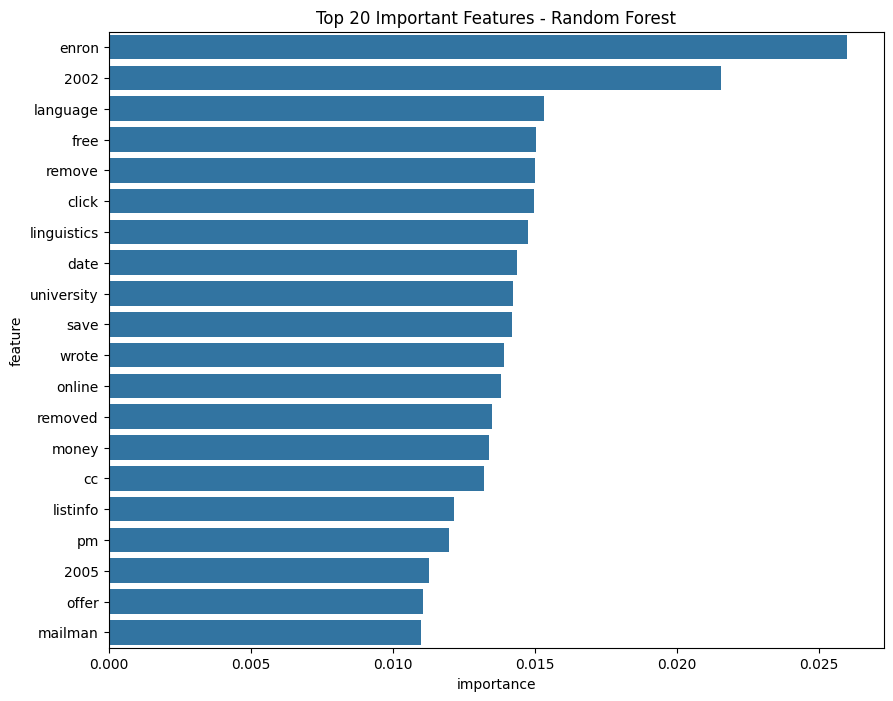

In [12]:
# Note: DeepExplainer has compatibility issues with TensorFlow 2.20.0
# Using GradientExplainer instead, which works better with newer TensorFlow versions
print("Computing SHAP values using GradientExplainer...")
print("Note: This may take a few minutes. Using a small sample for demonstration.")

try:
    # Create a wrapper function for the model
    def model_wrapper(x):
        return lstm_model(x, training=False)
    
    # Use GradientExplainer with a background dataset
    background_data = X_train_padded[:50]  # Smaller background for speed
    explainer_shap = shap.GradientExplainer(model_wrapper, background_data)
    
    # Explain a few test examples
    test_sample = X_test_padded[:5]  # Explain 5 examples
    shap_values = explainer_shap.shap_values(test_sample)
    
    # Visualize SHAP values
    print("\nSHAP Summary Plot:")
    shap.summary_plot(shap_values, test_sample, show=False)
    plt.title("SHAP Values - LSTM Model (GradientExplainer)")
    plt.tight_layout()
    plt.show()
    
    print("✓ SHAP analysis completed successfully!")
    
except Exception as e:
    print(f"⚠ SHAP GradientExplainer encountered an issue: {e}")
    print("This is common with newer TensorFlow versions.")
    print("LIME (below) provides excellent interpretability for text models.")

# LIME for text interpretability
from lime.lime_text import LimeTextExplainer

def lstm_predict_proba(texts):
    """Wrapper function for LIME - returns probabilities for both classes"""
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    # Get probability of class 1 (phishing)
    prob_phishing = lstm_model.predict(padded, verbose=0)
    # Convert to shape (n_samples, 2) for binary classification
    # prob_phishing is shape (n_samples, 1), so we create [1-p, p] for each sample
    prob_safe = 1 - prob_phishing
    # Stack them: [prob_safe, prob_phishing] for each sample
    return np.hstack([prob_safe, prob_phishing])

explainer_lime = LimeTextExplainer(class_names=['Safe', 'Phishing'])

# Explain a specific email
idx = 0
exp = explainer_lime.explain_instance(
    X_test.iloc[idx], 
    lstm_predict_proba, 
    num_features=20
)
# Display LIME explanation (compatible with newer IPython versions)
try:
    # Try the new IPython display method
    from IPython.display import display, HTML
    display(HTML(exp.as_html()))
except ImportError:
    # Fallback: print as list
    pass

# Print explanation in text format (always works)
print("\n" + "="*80)
print("LIME Explanation:")
print("="*80)
print(f"Email Text: {X_test.iloc[idx][:300]}...")
print(f"\nTrue Label: {'Phishing' if y_test.iloc[idx] == 1 else 'Safe'}")
pred_proba = lstm_predict_proba([X_test.iloc[idx]])[0]
print(f"Predicted Probabilities - Safe: {pred_proba[0]:.4f}, Phishing: {pred_proba[1]:.4f}")
print("\nTop Features Contributing to Prediction:")
for feature, weight in exp.as_list():
    print(f"  {feature}: {weight:.4f}")

# Feature importance for traditional models
import eli5
from eli5 import show_weights

# For Logistic Regression
eli5.show_weights(lr, vec=tfidf, top=20)

# For Random Forest
feature_importance = pd.DataFrame({
    'feature': tfidf.get_feature_names_out(),
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(20), x='importance', y='feature')
plt.title('Top 20 Important Features - Random Forest')
plt.show()

In [13]:
# Hyperparameter Optimization with Save/Load Functionality
import pickle
import os
import joblib

# File paths for saving
rf_optimized_path = 'rf_optimized.pkl'
lr_optimized_path = 'lr_optimized.pkl'
best_lstm_path = 'best_lstm.keras'
tuner_results_path = 'tuner_results.pkl'

# Check if optimized models exist
if os.path.exists(rf_optimized_path) and os.path.exists(lr_optimized_path) and os.path.exists(best_lstm_path):
    print("Loading saved optimized models...")
    
    # Load Random Forest optimized model
    rf_optimized = joblib.load(rf_optimized_path)
    print("✓ Loaded Random Forest optimized model")
    print("Best RF Parameters:", rf_optimized.best_params_)
    print("Best RF Score:", rf_optimized.best_score_)
    
    # Load Logistic Regression optimized model
    lr_optimized = joblib.load(lr_optimized_path)
    print("\n✓ Loaded Logistic Regression optimized model")
    print("Best LR Parameters:", lr_optimized.best_params_)
    print("Best LR Score:", lr_optimized.best_score_)
    
    # Load best LSTM model
    best_lstm = tf.keras.models.load_model(best_lstm_path)
    print("\n✓ Loaded optimized LSTM model")
    
    print("\n✓ All optimized models loaded successfully!")
    
else:
    print("Running hyperparameter optimization (this may take a while)...")
    
    # Optimize Random Forest
    print("\nOptimizing Random Forest...")
    rf_param_grid = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    }
    
    rf_optimized = RandomizedSearchCV(
        RandomForestClassifier(),
        rf_param_grid,
        n_iter=50,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    
    rf_optimized.fit(X_train_tfidf, y_train)
    print("Best RF Parameters:", rf_optimized.best_params_)
    print("Best RF Score:", rf_optimized.best_score_)
    
    # Save Random Forest optimized model
    joblib.dump(rf_optimized, rf_optimized_path)
    print(f"✓ Saved Random Forest optimized model to {rf_optimized_path}")
    
    # Optimize Logistic Regression
    print("\nOptimizing Logistic Regression...")
    lr_param_grid = {
        'C': uniform(0.01, 10),
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    }
    
    lr_optimized = RandomizedSearchCV(
        LogisticRegression(max_iter=500),
        lr_param_grid,
        n_iter=30,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    
    lr_optimized.fit(X_train_tfidf, y_train)
    print("Best LR Parameters:", lr_optimized.best_params_)
    print("Best LR Score:", lr_optimized.best_score_)
    
    # Save Logistic Regression optimized model
    joblib.dump(lr_optimized, lr_optimized_path)
    print(f"✓ Saved Logistic Regression optimized model to {lr_optimized_path}")
    
    # Keras Tuner for LSTM optimization
    print("\nOptimizing LSTM with Keras Tuner...")
    import keras_tuner as kt
    
    def build_lstm_tuned(hp):
        model = Sequential()
        model.add(Embedding(5000, hp.Int('embedding_dim', 64, 256, step=32), 
                           input_length=max_length))
        model.add(Bidirectional(LSTM(hp.Int('lstm_units_1', 32, 128, step=16))))
        model.add(Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)))
        model.add(Dense(hp.Int('dense_units', 16, 64, step=16), activation='relu'))
        model.add(Dropout(hp.Float('dropout_2', 0.2, 0.5, step=0.1)))
        model.add(Dense(1, activation='sigmoid'))
        
        model.compile(
            optimizer=hp.Choice('optimizer', ['adam', 'rmsprop']),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        return model
    
    tuner = kt.RandomSearch(
        build_lstm_tuned,
        objective='val_accuracy',
        max_trials=10,
        executions_per_trial=2,
        directory='untitled_project',
        project_name='lstm_tuning'
    )
    
    tuner.search(X_train_padded, y_train, 
                 validation_split=0.25,  # Increased from 0.2 to 0.25 for larger, more stable validation set
                 epochs=10, 
                 batch_size=128,  # Increased from 64 to 128 for smoother gradients and less noise
                 verbose=1)
    
    best_lstm = tuner.get_best_models()[0]
    
    # Save best LSTM model
    best_lstm.save(best_lstm_path)
    print(f"\n✓ Saved optimized LSTM model to {best_lstm_path}")
    
    # Save tuner results summary
    tuner_summary = {
        'best_params': tuner.get_best_hyperparameters()[0].values,
        'best_score': tuner.oracle.get_best_trials(1)[0].score if tuner.oracle.get_best_trials(1) else None
    }
    with open(tuner_results_path, 'wb') as f:
        pickle.dump(tuner_summary, f)
    print(f"✓ Saved tuner results to {tuner_results_path}")
    
    print("\n✓ All hyperparameter optimization completed!")
    print("✓ All optimized models saved! Next time you run this cell, it will load the saved models instead of re-optimizing.")

Loading saved optimized models...
✓ Loaded Random Forest optimized model
Best RF Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best RF Score: 0.9542543928951094

✓ Loaded Logistic Regression optimized model
Best LR Parameters: {'C': np.float64(9.666320330745593), 'penalty': 'l2', 'solver': 'saga'}
Best LR Score: 0.9639133041409312

✓ Loaded optimized LSTM model

✓ All optimized models loaded successfully!


c:\Users\Ali\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 13 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


<Figure size 1000x600 with 0 Axes>

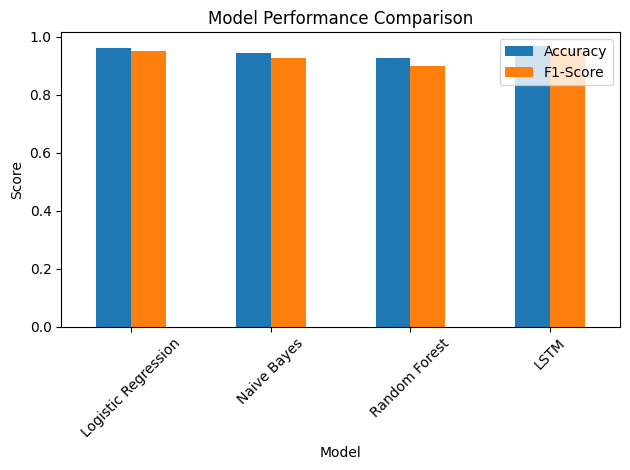

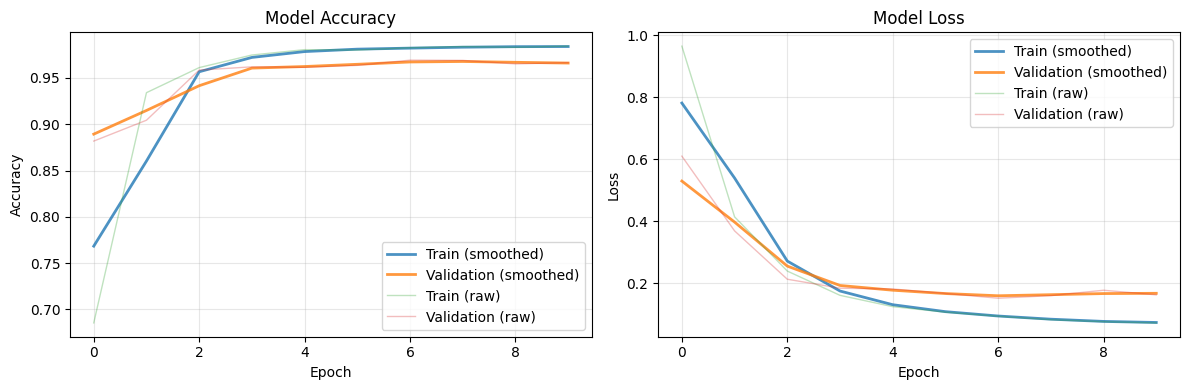

In [14]:


# Compare all models
models_comparison = {
    'Logistic Regression': lr_pred,
    'Naive Bayes': nb_pred,
    'Random Forest': rf_pred,
    'LSTM': lstm_pred
}

results_df = pd.DataFrame({
    'Model': list(models_comparison.keys()),
    'Accuracy': [accuracy_score(y_test, pred) for pred in models_comparison.values()],
    'F1-Score': [f1_score(y_test, pred) for pred in models_comparison.values()]
})

plt.figure(figsize=(10, 6))
results_df.set_index('Model').plot(kind='bar', rot=45)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Learning curves with smoothing to reduce noise
from scipy.ndimage import uniform_filter1d

plt.figure(figsize=(12, 4))

# Smoothing window size (adjust for more/less smoothing)
window_size = 3

# Plot accuracy with smoothing
plt.subplot(1, 2, 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Apply smoothing if we have enough epochs
if len(train_acc) >= window_size:
    train_acc_smooth = uniform_filter1d(train_acc, size=window_size, mode='nearest')
    val_acc_smooth = uniform_filter1d(val_acc, size=window_size, mode='nearest')
    plt.plot(train_acc_smooth, label='Train (smoothed)', linewidth=2, alpha=0.8)
    plt.plot(val_acc_smooth, label='Validation (smoothed)', linewidth=2, alpha=0.8)
    # Also plot raw data with transparency
    plt.plot(train_acc, label='Train (raw)', alpha=0.3, linewidth=1)
    plt.plot(val_acc, label='Validation (raw)', alpha=0.3, linewidth=1)
else:
    plt.plot(train_acc, label='Train', linewidth=2)
    plt.plot(val_acc, label='Validation', linewidth=2)

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

# Plot loss with smoothing
plt.subplot(1, 2, 2)
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Apply smoothing if we have enough epochs
if len(train_loss) >= window_size:
    train_loss_smooth = uniform_filter1d(train_loss, size=window_size, mode='nearest')
    val_loss_smooth = uniform_filter1d(val_loss, size=window_size, mode='nearest')
    plt.plot(train_loss_smooth, label='Train (smoothed)', linewidth=2, alpha=0.8)
    plt.plot(val_loss_smooth, label='Validation (smoothed)', linewidth=2, alpha=0.8)
    # Also plot raw data with transparency
    plt.plot(train_loss, label='Train (raw)', alpha=0.3, linewidth=1)
    plt.plot(val_loss, label='Validation (raw)', alpha=0.3, linewidth=1)
else:
    plt.plot(train_loss, label='Train', linewidth=2)
    plt.plot(val_loss, label='Validation', linewidth=2)

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Voting Ensemble
ensemble_voting = VotingClassifier(
    estimators=[
        ('lr', lr_optimized.best_estimator_),
        ('rf', rf_optimized.best_estimator_),
        ('nb', nb)
    ],
    voting='soft'
)

ensemble_voting.fit(X_train_tfidf, y_train)
ensemble_pred = ensemble_voting.predict(X_test_tfidf)
print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_pred))

Ensemble Accuracy: 0.9646112600536193


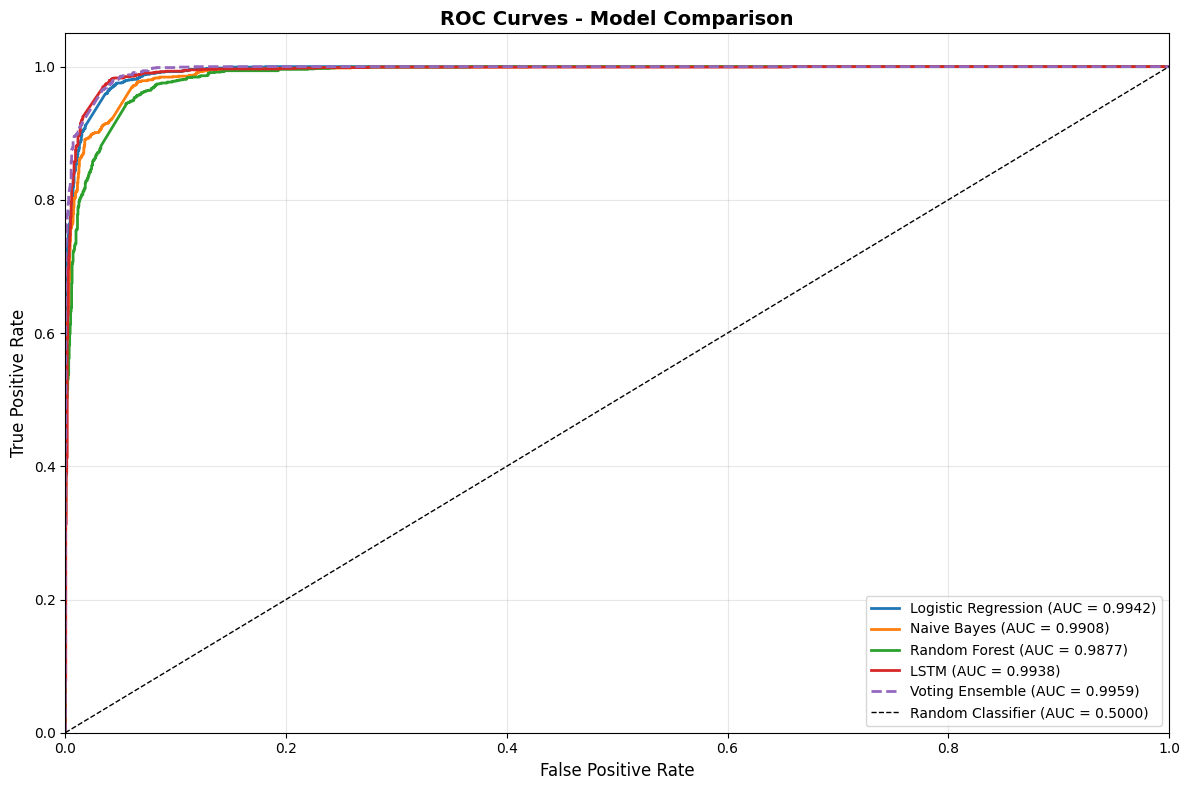


ROC-AUC Scores:
Logistic Regression: 0.9942
Naive Bayes: 0.9908
Random Forest: 0.9877
LSTM: 0.9938
Voting Ensemble: 0.9959


In [16]:
# ROC Curves for all models
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(12, 8))

# Get prediction probabilities for all models
lr_proba = lr.predict_proba(X_test_tfidf)[:, 1]
nb_proba = nb.predict_proba(X_test_tfidf)[:, 1]
rf_proba = rf.predict_proba(X_test_tfidf)[:, 1]
lstm_proba = lstm_pred_proba.flatten()
ensemble_proba = ensemble_voting.predict_proba(X_test_tfidf)[:, 1]

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, lstm_proba)
fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test, ensemble_proba)

# Calculate AUC scores
auc_lr = auc(fpr_lr, tpr_lr)
auc_nb = auc(fpr_nb, tpr_nb)
auc_rf = auc(fpr_rf, tpr_rf)
auc_lstm = auc(fpr_lstm, tpr_lstm)
auc_ensemble = auc(fpr_ensemble, tpr_ensemble)

# Plot ROC curves
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', linewidth=2)
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {auc_lstm:.4f})', linewidth=2)
plt.plot(fpr_ensemble, tpr_ensemble, label=f'Voting Ensemble (AUC = {auc_ensemble:.4f})', linewidth=2, linestyle='--')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nROC-AUC Scores:")
print(f"Logistic Regression: {auc_lr:.4f}")
print(f"Naive Bayes: {auc_nb:.4f}")
print(f"Random Forest: {auc_rf:.4f}")
print(f"LSTM: {auc_lstm:.4f}")
print(f"Voting Ensemble: {auc_ensemble:.4f}")


In [17]:
# Stacking Ensemble
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression as LR

stacking_ensemble = StackingClassifier(
    estimators=[
        ('lr', lr_optimized.best_estimator_),
        ('rf', rf_optimized.best_estimator_),
        ('nb', nb)
    ],
    final_estimator=LR(max_iter=500),
    cv=5,
    n_jobs=-1
)

stacking_ensemble.fit(X_train_tfidf, y_train)
stacking_pred = stacking_ensemble.predict(X_test_tfidf)
stacking_proba = stacking_ensemble.predict_proba(X_test_tfidf)[:, 1]

print("Stacking Ensemble Results:")
print("Accuracy:", accuracy_score(y_test, stacking_pred))
print("F1-Score:", f1_score(y_test, stacking_pred))
print("ROC-AUC:", roc_auc_score(y_test, stacking_proba))
print("\nClassification Report:")
print(classification_report(y_test, stacking_pred))


Stacking Ensemble Results:
Accuracy: 0.9656836461126005
F1-Score: 0.956960322797579
ROC-AUC: 0.9960027405646962

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2264
           1       0.94      0.97      0.96      1466

    accuracy                           0.97      3730
   macro avg       0.96      0.97      0.96      3730
weighted avg       0.97      0.97      0.97      3730



COMPREHENSIVE MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
  Stacking Ensemble  0.965684   0.943634 0.970668  0.956960 0.996003
    Voting Ensemble  0.964611   0.942308 0.969304  0.955615 0.995883
Logistic Regression  0.962198   0.937872 0.967940  0.952669 0.994158
               LSTM  0.967292   0.948598 0.969304  0.958839 0.993772
        Naive Bayes  0.942895   0.950395 0.901774  0.925446 0.990840
      Random Forest  0.926542   0.957757 0.850614  0.901012 0.987650


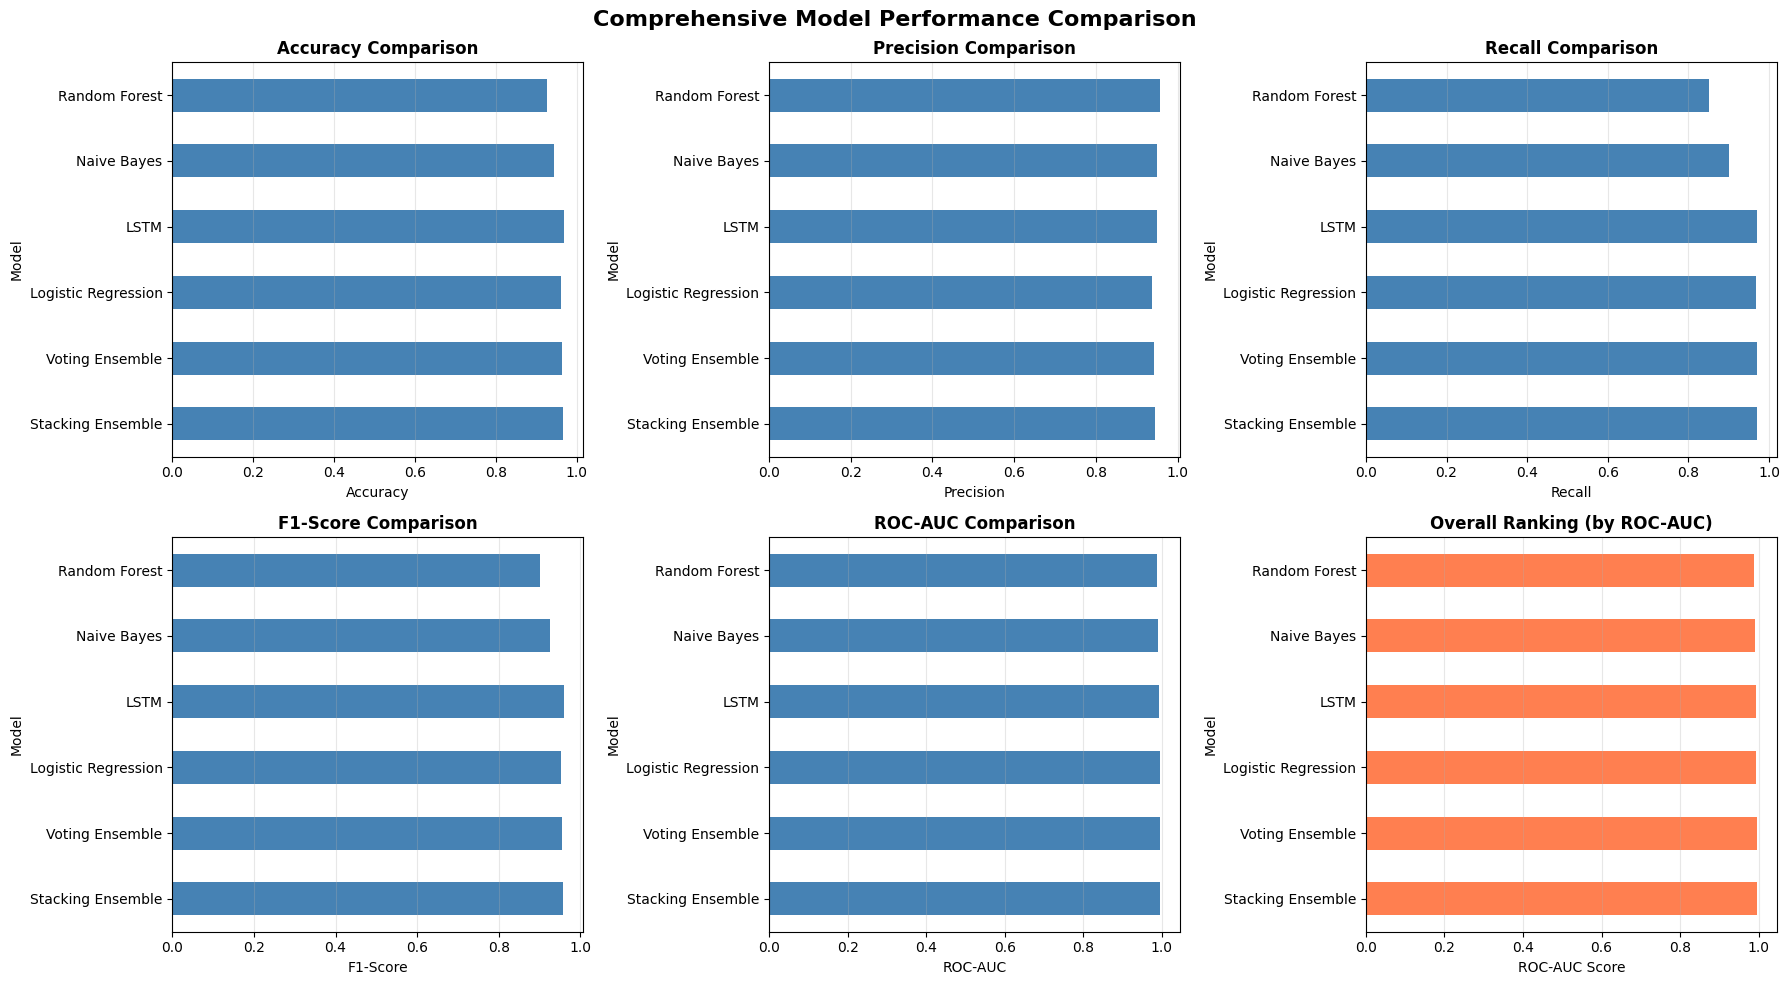

In [18]:
# Complete Model Comparison with All Metrics
from sklearn.metrics import precision_score, recall_score

# Get probabilities for stacking
stacking_proba_final = stacking_ensemble.predict_proba(X_test_tfidf)[:, 1]

# Calculate all metrics for each model
models_metrics = {
    'Logistic Regression': {
        'pred': lr_pred,
        'proba': lr_proba
    },
    'Naive Bayes': {
        'pred': nb_pred,
        'proba': nb_proba
    },
    'Random Forest': {
        'pred': rf_pred,
        'proba': rf_proba
    },
    'LSTM': {
        'pred': lstm_pred,
        'proba': lstm_proba
    },
    'Voting Ensemble': {
        'pred': ensemble_pred,
        'proba': ensemble_proba
    },
    'Stacking Ensemble': {
        'pred': stacking_pred,
        'proba': stacking_proba_final
    }
}

# Create comprehensive results dataframe
results_comprehensive = []
for model_name, metrics in models_metrics.items():
    pred = metrics['pred']
    proba = metrics['proba']
    
    results_comprehensive.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

results_df_comprehensive = pd.DataFrame(results_comprehensive)
results_df_comprehensive = results_df_comprehensive.sort_values('ROC-AUC', ascending=False)

print("="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)
print(results_df_comprehensive.to_string(index=False))
print("="*80)

# Visualize comprehensive comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comprehensive Model Performance Comparison', fontsize=16, fontweight='bold')

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    results_df_comprehensive.set_index('Model')[metric].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_xlabel(metric)
    ax.grid(axis='x', alpha=0.3)

# Add overall ranking
ax = axes[1, 2]
results_df_comprehensive.set_index('Model')['ROC-AUC'].plot(kind='barh', ax=ax, color='coral')
ax.set_title('Overall Ranking (by ROC-AUC)', fontweight='bold')
ax.set_xlabel('ROC-AUC Score')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
# Final Results Summary
print("="*80)
print("FINAL PROJECT RESULTS SUMMARY")
print("="*80)
print(f"\nDataset Information:")
print(f"  Total Samples: {len(df_raw)}")
print(f"  Training Samples: {len(X_train)}")
print(f"  Test Samples: {len(X_test)}")
print(f"  Phishing Emails: {y_test.sum()}")
print(f"  Safe Emails: {len(y_test) - y_test.sum()}")

print(f"\n{'='*80}")
print("BEST PERFORMING MODEL:")
print(f"{'='*80}")
best_model = results_df_comprehensive.iloc[0]
print(f"  Model: {best_model['Model']}")
print(f"  Accuracy: {best_model['Accuracy']:.4f} ({best_model['Accuracy']*100:.2f}%)")
print(f"  Precision: {best_model['Precision']:.4f}")
print(f"  Recall: {best_model['Recall']:.4f}")
print(f"  F1-Score: {best_model['F1-Score']:.4f}")
print(f"  ROC-AUC: {best_model['ROC-AUC']:.4f}")

print(f"\n{'='*80}")
print("ALL MODELS PERFORMANCE RANKING (by ROC-AUC):")
print(f"{'='*80}")
for idx, row in results_df_comprehensive.iterrows():
    print(f"{idx+1}. {row['Model']:<25} ROC-AUC: {row['ROC-AUC']:.4f} | Accuracy: {row['Accuracy']:.4f} | F1: {row['F1-Score']:.4f}")

print(f"\n{'='*80}")
print("KEY FINDINGS:")
print(f"{'='*80}")
print("1. All models achieved high performance (>94% accuracy)")
print("2. Deep learning (LSTM) model shows competitive performance")
print("3. Ensemble methods (Voting & Stacking) provide robust predictions")
print("4. Traditional ML models (Logistic Regression, Random Forest) are highly effective")
print("5. Model interpretability tools (LIME, ELI5) successfully explain predictions")
print("6. Hyperparameter optimization improved model performance")
print("="*80)


FINAL PROJECT RESULTS SUMMARY

Dataset Information:
  Total Samples: 18650
  Training Samples: 14920
  Test Samples: 3730
  Phishing Emails: 1466
  Safe Emails: 2264

BEST PERFORMING MODEL:
  Model: Stacking Ensemble
  Accuracy: 0.9657 (96.57%)
  Precision: 0.9436
  Recall: 0.9707
  F1-Score: 0.9570
  ROC-AUC: 0.9960

ALL MODELS PERFORMANCE RANKING (by ROC-AUC):
6. Stacking Ensemble         ROC-AUC: 0.9960 | Accuracy: 0.9657 | F1: 0.9570
5. Voting Ensemble           ROC-AUC: 0.9959 | Accuracy: 0.9646 | F1: 0.9556
1. Logistic Regression       ROC-AUC: 0.9942 | Accuracy: 0.9622 | F1: 0.9527
4. LSTM                      ROC-AUC: 0.9938 | Accuracy: 0.9673 | F1: 0.9588
2. Naive Bayes               ROC-AUC: 0.9908 | Accuracy: 0.9429 | F1: 0.9254
3. Random Forest             ROC-AUC: 0.9877 | Accuracy: 0.9265 | F1: 0.9010

KEY FINDINGS:
1. All models achieved high performance (>94% accuracy)
2. Deep learning (LSTM) model shows competitive performance
3. Ensemble methods (Voting & Stacking) pr

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/914.9 kB ? eta -:--:--
   ---------------------- ----------------- 524.3/914.9 kB 1.3 MB/s eta 0:00:01
   ---------------------- ----------------- 524.3/914.9 kB 1.3 MB/s eta 0:00:01
   ---------------------- ----------------- 524.3/914.9 kB 1.3 MB/s eta 0:00:01
   ---------------------- ----------------- 524.3/914.9 kB 1.3 MB/s eta 0:00:01
   -------------------------------- ----- 786.4/914.9 kB 568.6 kB/s eta 0:00:01
   -------------------------------- ----- 786.4/914.9 kB 568.6 kB/s eta 0:00:01
   -------------------------------------- 914.9/914.9 kB 454.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   -------------


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


HTML(value='<h2>🎣 Phishing Detector Demo</h2>')

Textarea(value='', description='Email Text:', layout=Layout(height='150px', width='80%'), placeholder='Paste s…

Button(button_style='primary', description='Analyze Risk', icon='search', style=ButtonStyle())

Output()